# Desafio - Análise de Dados e Storytelling

## Definição do Problema

Este projeto tem como objetivo analisar a incidência de casos de dengue no estado de São Paulo entre os anos de 2013 e 2023.

A análise busca identificar padrões, tendências ao longo do tempo e possíveis períodos de surtos, utilizando técnicas de análise de dados e visualização.

A partir disso, serão gerados insights que possam contribuir para a compreensão do comportamento da doença e apoiar possíveis ações de prevenção.

## Exploração dos Dados



In [37]:
# Bibliotecas para manipulação e análise de dados
import pandas as pd
import numpy as np

# Bibliotecas para visualização de dados
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [38]:
# Lê o arquivo Excel e armazena no DataFrame df_dengue
df_dengue = pd.read_excel('/content/sample_data/Base de Dados Dengue.xlsx')

# Exibe as primeiras 5 linhas do DataFrame (índice começa em 0)
df_dengue.head()

,municipio,uf,data_infeccoes,qtd_infeccoes
0,ALTA FLORESTA D'OESTE,RO,2013-01-01,34
1,ALTA FLORESTA D'OESTE,RO,2013-02-01,44
2,ALTA FLORESTA D'OESTE,RO,2013-03-01,15
3,ALTA FLORESTA D'OESTE,RO,2013-04-01,4
4,ALTA FLORESTA D'OESTE,RO,2013-05-01,3


In [39]:
# Ajusta o formato da data
df_dengue['data_infeccoes'] = pd.to_datetime(df_dengue['data_infeccoes'])

# Verifica os tipos
df_dengue.dtypes

,0
municipio,object
uf,object
data_infeccoes,datetime64[ns]
qtd_infeccoes,int64


In [40]:
# Cria coluna com o ano
df_dengue['ano'] = df_dengue['data_infeccoes'].dt.year

# Visualiza para conferir
df_dengue.head()

,municipio,uf,data_infeccoes,qtd_infeccoes,ano
0,ALTA FLORESTA D'OESTE,RO,2013-01-01,34,2013
1,ALTA FLORESTA D'OESTE,RO,2013-02-01,44,2013
2,ALTA FLORESTA D'OESTE,RO,2013-03-01,15,2013
3,ALTA FLORESTA D'OESTE,RO,2013-04-01,4,2013
4,ALTA FLORESTA D'OESTE,RO,2013-05-01,3,2013


In [41]:
# Filtra apenas os dados do estado de São Paulo (SP)
df_sp = df_dengue.loc[df_dengue['uf'] == 'SP']

# Visualiza
df_sp.head()

,municipio,uf,data_infeccoes,qtd_infeccoes,ano
430584,ADAMANTINA,SP,2013-01-01,10,2013
430585,ADAMANTINA,SP,2013-02-01,61,2013
430586,ADAMANTINA,SP,2013-03-01,173,2013
430587,ADAMANTINA,SP,2013-04-01,32,2013
430588,ADAMANTINA,SP,2013-05-01,20,2013


In [42]:
df_sp['uf'].unique()

array(['SP'], dtype=object)

In [43]:
# Verifica os anos disponíveis em SP
df_sp['ano'].unique()

array([2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023],
      dtype=int32)

In [44]:
# Agrupa os dados por ano e calcula o total de casos de dengue no estado de São Paulo
casos_por_ano_sp = df_sp.groupby('ano')['qtd_infeccoes'].sum().reset_index()

# Visualiza
casos_por_ano_sp

,ano,qtd_infeccoes
0,2013,121219
1,2014,109342
2,2015,286000
3,2016,77559
4,2017,5038
5,2018,10098
6,2019,178852
7,2020,109705
8,2021,105707
9,2022,177043


## Análises + Gráficos

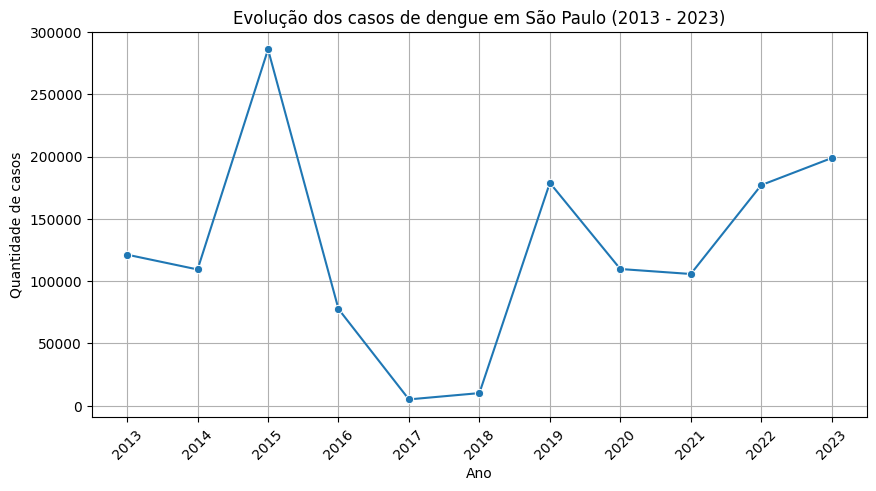

In [45]:
# Cria um gráfico de linha para visualizar a evolução dos casos ao longo dos anos em SP
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=casos_por_ano_sp,
    x='ano',
    y='qtd_infeccoes',
    marker='o'
)

# Títulos
plt.title('Evolução dos casos de dengue em São Paulo (2013 - 2023)')
plt.xlabel('Ano')
plt.ylabel('Quantidade de casos')
plt.xticks(casos_por_ano_sp['ano'], rotation=45)

plt.grid(True)

plt.show()

## Storytelling

## Interpretação

O gráfico mostra a evolução dos casos de dengue no estado de São Paulo entre 2013 e 2023. Observa-se uma grande variação ao longo dos anos, com destaque para um pico expressivo em 2015, indicando um possível surto da doença nesse período.

Após esse aumento, houve uma queda significativa nos anos seguintes, especialmente entre 2016 e 2018. A partir de 2019, os casos voltam a crescer, mantendo níveis elevados até 2023.

Esse comportamento indica que a dengue apresenta ciclos de aumento e redução, reforçando a importância do monitoramento contínuo e de ações preventivas para controle da doença.

In [46]:
# Agrupa por município e soma os casos
municipios_sp = df_sp.groupby('municipio')['qtd_infeccoes'].sum().reset_index()

# Ordena do maior para o menor
municipios_sp = municipios_sp.sort_values(by='qtd_infeccoes', ascending=False)

# Pega top 10
top10_municipios = municipios_sp.head(10)

top10_municipios

,municipio,qtd_infeccoes
564,SAO PAULO,138048
558,SAO JOSE DO RIO PRETO,75073
489,RIBEIRAO PRETO,46014
466,PRESIDENTE PRUDENTE,43649
67,BAURU,38764
583,SOROCABA,29049
108,CAMPINAS,26189
214,GUARULHOS,23911
605,TATUI,19914
328,MARILIA,19321


/tmp/ipykernel_5643/191318811.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


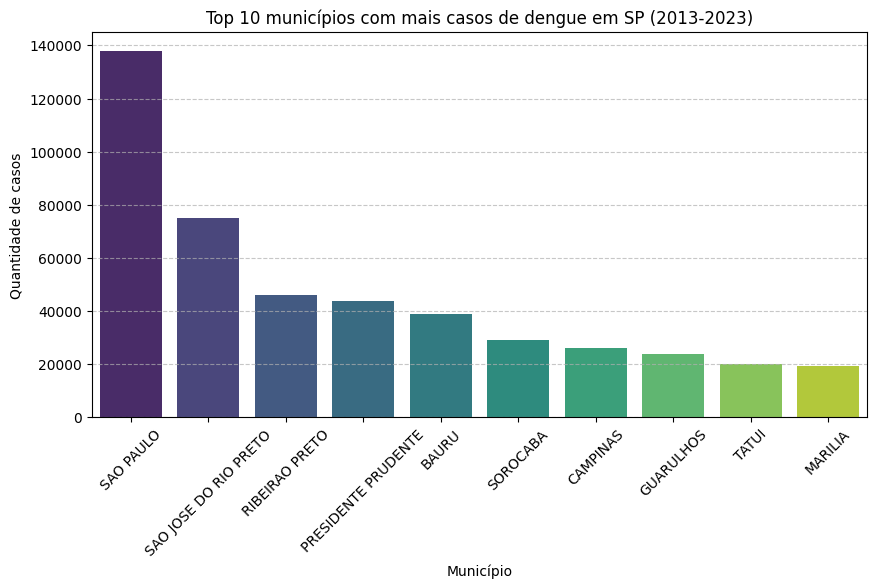

In [47]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=top10_municipios,
    x ='municipio',
    y ='qtd_infeccoes',
    palette ='viridis'
)

plt.xticks(rotation=45)
plt.title('Top 10 municípios com mais casos de dengue em SP (2013-2023)')
plt.xlabel('Município')
plt.ylabel('Quantidade de casos')
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)

plt.show()

## Interpretação

Os dados mostram que poucos municípios concentram a maior parte dos casos de dengue, indicando regiões mais críticas que demandam maior atenção das políticas públicas.

A análise foi focada nos principais municípios para garantir melhor visualização e interpretação dos dados.

In [48]:
# Agrupa por ano e município (SP)
municipios_ano_sp = df_sp.groupby(['ano', 'municipio'])['qtd_infeccoes'].sum().reset_index()

# Visualiza
municipios_ano_sp.head()

,ano,municipio,qtd_infeccoes
0,2013,ADAMANTINA,320
1,2013,ADOLFO,29
2,2013,AGUAI,281
3,2013,AGUAS DA PRATA,1
4,2013,AGUAS DE LINDOIA,7


In [49]:
# Soma total por município (SP)
municipios_total_sp = df_sp.groupby('municipio')['qtd_infeccoes'].sum().reset_index()

# Ordena do maior para o menor
municipios_total_sp = municipios_total_sp.sort_values(by='qtd_infeccoes', ascending=False)

# Visualiza
municipios_total_sp.head()

,municipio,qtd_infeccoes
564,SAO PAULO,138048
558,SAO JOSE DO RIO PRETO,75073
489,RIBEIRAO PRETO,46014
466,PRESIDENTE PRUDENTE,43649
67,BAURU,38764


In [50]:
top10_municipios = municipios_total_sp.head(10)

top10_municipios

,municipio,qtd_infeccoes
564,SAO PAULO,138048
558,SAO JOSE DO RIO PRETO,75073
489,RIBEIRAO PRETO,46014
466,PRESIDENTE PRUDENTE,43649
67,BAURU,38764
583,SOROCABA,29049
108,CAMPINAS,26189
214,GUARULHOS,23911
605,TATUI,19914
328,MARILIA,19321


/tmp/ipykernel_5643/3476191468.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


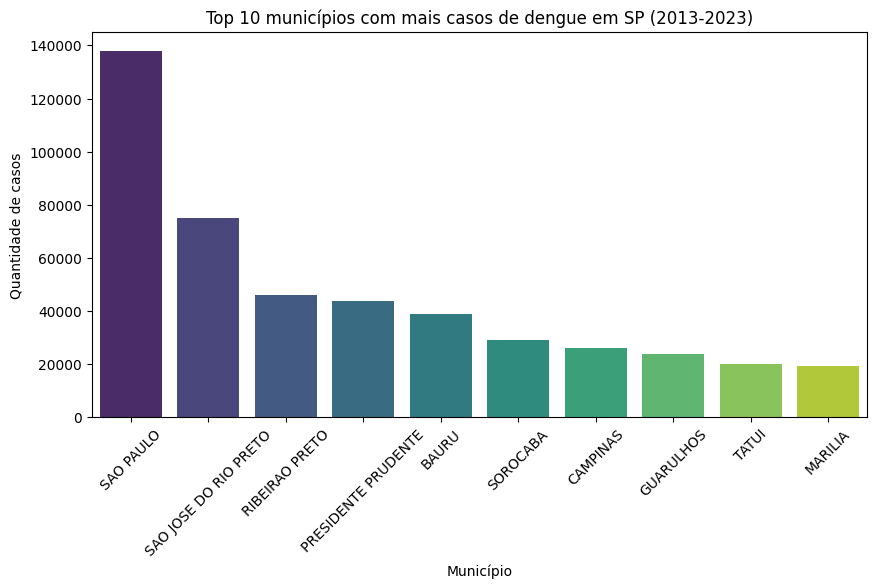

In [51]:
# Cria gráfico de barras dos top 10 municípios
plt.figure(figsize=(10, 5))

sns.barplot(
    data=top10_municipios,
    x ='municipio',
    y ='qtd_infeccoes',
    palette ='viridis'
)

# Rotaciona nomes das cidades
plt.xticks(rotation = 45)

# Títulos
plt.title('Top 10 municípios com mais casos de dengue em SP (2013-2023)')
plt.xlabel('Município')
plt.ylabel('Quantidade de casos')

plt.show()

## Interpretação

Os dados mostram que poucos municípios concentram a maior parte dos casos de dengue no estado de São Paulo. A capital lidera com grande diferença em relação às demais cidades, seguida por municípios como São José do Rio Preto e Ribeirão Preto.

Esse padrão indica que áreas mais populosas ou com maior densidade urbana tendem a registrar mais casos, reforçando a necessidade de ações de controle direcionadas para essas regiões.

In [52]:
total_sp = df_sp['qtd_infeccoes'].sum()

# Cria coluna de percentual
municipios_total_sp['percentual'] = (municipios_total_sp['qtd_infeccoes'] / total_sp) * 100

municipios_total_sp.head()

,municipio,qtd_infeccoes,percentual
564,SAO PAULO,138048,10.008287
558,SAO JOSE DO RIO PRETO,75073,5.442687
489,RIBEIRAO PRETO,46014,3.335951
466,PRESIDENTE PRUDENTE,43649,3.164491
67,BAURU,38764,2.810336


In [53]:
top10_municipios = municipios_total_sp.head(10)

top10_municipios

,municipio,qtd_infeccoes,percentual
564,SAO PAULO,138048,10.008287
558,SAO JOSE DO RIO PRETO,75073,5.442687
489,RIBEIRAO PRETO,46014,3.335951
466,PRESIDENTE PRUDENTE,43649,3.164491
67,BAURU,38764,2.810336
583,SOROCABA,29049,2.106012
108,CAMPINAS,26189,1.898666
214,GUARULHOS,23911,1.733514
605,TATUI,19914,1.443737
328,MARILIA,19321,1.400745


/tmp/ipykernel_5643/2709169620.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


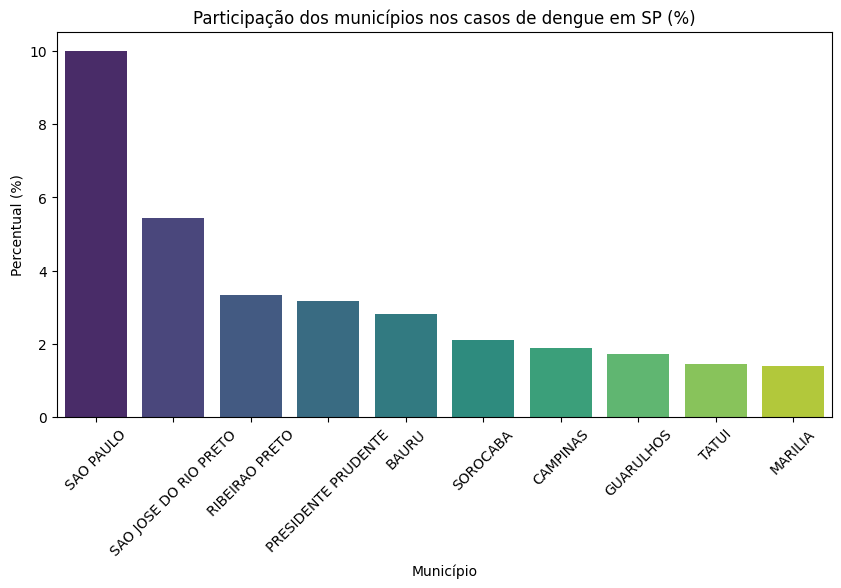

In [54]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=top10_municipios,
    x='municipio',
    y='percentual',
    palette='viridis'
)

plt.xticks(rotation=45)

plt.title('Participação dos municípios nos casos de dengue em SP (%)')
plt.xlabel('Município')
plt.ylabel('Percentual (%)')

plt.show()

## Interpretação

Os dados mostram que poucos municípios concentram uma grande parcela dos casos de dengue no estado de São Paulo. A capital possui a maior participação, seguida por outras cidades de médio e grande porte.

Esse resultado indica uma concentração da doença em regiões específicas, reforçando a necessidade de ações direcionadas para controle e prevenção nesses locais.

Como não havia dados de população disponíveis na base utilizada, foi calculado um indicador percentual para representar a participação de cada município no total de casos.

## Conclusão final
A análise demonstrou que os casos de dengue no estado de São Paulo apresentam comportamento cíclico ao longo dos anos, com ocorrência de picos que indicam surtos da doença.

Observou-se também que poucos municípios concentram a maior parte dos casos, com destaque para a capital e cidades de maior porte, indicando forte relação com densidade populacional.

Além disso, a análise percentual evidenciou a concentração da doença em regiões específicas, permitindo uma visão mais clara do impacto da dengue no estado.

Esses resultados reforçam a importância do monitoramento contínuo e da adoção de ações preventivas direcionadas.

In [56]:
top10_municipios = municipios_total_sp.head(10)
top10_municipios

,municipio,qtd_infeccoes,percentual
564,SAO PAULO,138048,10.008287
558,SAO JOSE DO RIO PRETO,75073,5.442687
489,RIBEIRAO PRETO,46014,3.335951
466,PRESIDENTE PRUDENTE,43649,3.164491
67,BAURU,38764,2.810336
583,SOROCABA,29049,2.106012
108,CAMPINAS,26189,1.898666
214,GUARULHOS,23911,1.733514
605,TATUI,19914,1.443737
328,MARILIA,19321,1.400745
